In [ ]:
### load tree
from treeswift import read_tree_newick
tree_file = "../figure_3b/dsdna_normscores.nwk"
tree = read_tree_newick(tree_file)
print(tree.diameter())

In [2]:
### map seq_names to nodes
map_all = tree.label_to_node(selection='all')

In [3]:
import polars as pl
dsdna_viruses = pl.read_csv('../dsdna_annotations/all_dsdna_annotations.tsv', separator='\t')

In [4]:
### % of dsDNA genomes that are complete
import polars as pl
print(
    dsdna_viruses
        .filter(pl.col('checkv_quality') == 'Complete').height / dsdna_viruses.height
)

0.2673895914700164


In [5]:
### % of dsDNA genomes that are Caudoviricetes
import polars as pl
print(
    dsdna_viruses
        .filter(pl.col('ictv_class') == 'Caudoviricetes').height / dsdna_viruses.height
)

0.9998016019227608


In [8]:
### % of dsDNA genomes that are Caudoviricetes
for body_site in ['Gut', 'Airways', 'Skin', 'Urogenital']:
    print("Prop dsdna in", body_site,
        dsdna_viruses
            .filter(pl.col('body_site') == body_site).height / dsdna_viruses.height
    )

Prop dsdna in Gut 0.42580195337078336
Prop dsdna in Airways 0.4927244590818137
Prop dsdna in Skin 0.010656811005991623
Prop dsdna in Urogenital 0.011115960841888069


In [9]:
print("Prop all that are from assembly:",
    dsdna_viruses
        .filter(pl.col('db_type') == 'Assembly').height / 
    dsdna_viruses.height
)

Prop all that are from assembly: 0.3298566432179034


In [10]:
### calculate pairwise distance between 1,000 random nodes
import polars as pl

dsdna_viruses = (
    pl.read_csv('../dsdna_annotations/all_dsdna_annotations.tsv', separator='\t')
        .filter(pl.col('seq_name').is_in(set(map_all.keys())))
)
rand_1k = dsdna_viruses.sample(1000, seed=0)['seq_name'].to_list()

# calculate lower triangle distance matrix for random 1k
dist_1k_lst = []

for i in range(len(rand_1k)):
    for j in range(i+1, len(rand_1k)):
        dist_1k_lst.append(tree.distance_between(map_all[rand_1k[i]], map_all[rand_1k[j]])) 

print("Average pairwise distance of 1K random species:", sum(dist_1k_lst) / len(dist_1k_lst))

Average pairwise distance of 1K random species: 2.1714355425214946


In [11]:
dsdna_viruses.unique('cluster_id')['cluster_id'].to_list()

['cluster_8',
 'cluster_12',
 'cluster_10',
 'cluster_13',
 'cluster_11',
 'cluster_2',
 'cluster_6',
 'cluster_5',
 None,
 'cluster_3',
 'cluster_9']

In [14]:
### calculate pairwise distance between 1,000 intra-family species
import polars as pl

intra_family_dist = []

for family in ['cluster_8',
 'cluster_12',
 'cluster_10',
 'cluster_13',
 'cluster_11',
 'cluster_2',
 'cluster_6',
 'cluster_5',
 'cluster_3',
 'cluster_9']:
    print("Processing family:", family)
    intra_family_viruses = (
        dsdna_viruses
            .filter(pl.col('seq_name').is_in(set(map_all.keys())))
            .filter(pl.col('cluster_id') == family)
    )
    if intra_family_viruses.height < 1000:
        subsample_size = intra_family_viruses.height
    else:
        subsample_size = 1000
    rand_1k = intra_family_viruses.sample(subsample_size, seed=0)['seq_name'].to_list()

    for i in range(len(rand_1k)):
        for j in range(i+1, len(rand_1k)):
            intra_family_dist.append(tree.distance_between(map_all[rand_1k[i]], map_all[rand_1k[j]])) 

print("Average pairwise distance of intra-family species:", sum(intra_family_dist) / len(intra_family_dist))
print("Median pairwise distance of intra-family species:", sorted(intra_family_dist)[len(intra_family_dist)//2])

Processing family: cluster_8
Processing family: cluster_12
Processing family: cluster_10
Processing family: cluster_13
Processing family: cluster_11
Processing family: cluster_2
Processing family: cluster_6
Processing family: cluster_5
Processing family: cluster_3
Processing family: cluster_9
Average pairwise distance of intra-family species: 2.1123996728078613
Median pairwise distance of intra-family species: 2.0766


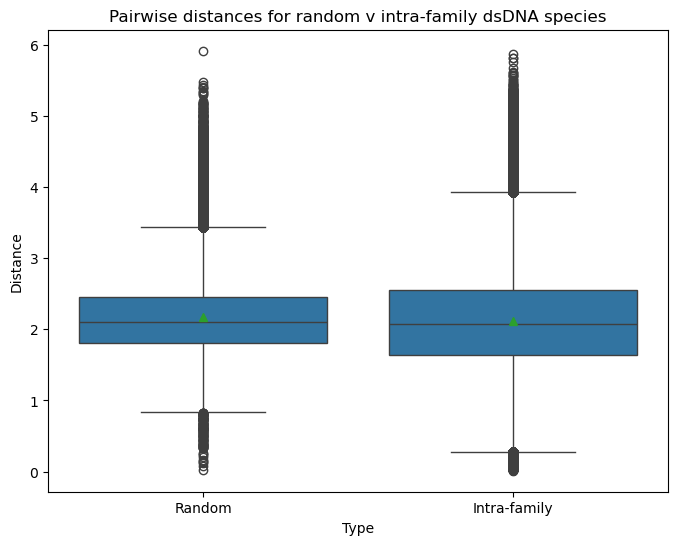

In [17]:
### create boxplot of distances for random vs intra-family
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

dist_df = pd.DataFrame({
    'Distance': dist_1k_lst + intra_family_dist,
    'Type': ['Random'] * len(dist_1k_lst) + ['Intra-family'] * len(intra_family_dist)
})
plt.figure(figsize=(8,6))
sns.boxplot(x='Type', y='Distance', data=dist_df, showmeans=True)
plt.title('Pairwise distances for random v intra-family dsDNA species')
plt.show()

In [18]:
votu_info = pl.read_csv('../../figure_2/vclust/uhvdb_vclust_cluster_info_final.tsv', separator='\t').rename({'contig_id':'seq_name'})[['seq_name', 'length', 'num_seqs']]
dsdna_viruses = dsdna_viruses.join(votu_info, on='seq_name', how='inner')

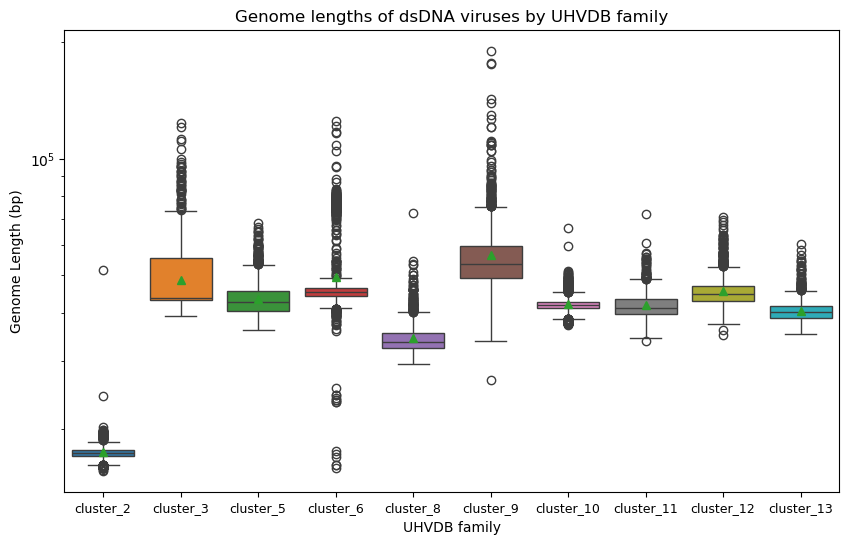

In [27]:
# create a boxplot of the lengths of ssDNA viruses by class
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

length_df = pd.DataFrame({
    'Length': dsdna_viruses.with_columns([pl.col('cluster_id').str.replace('cluster_', '').cast(pl.Int32).alias('cluster_num')]).sort('cluster_num')['length'].to_list(),
    'UHVDB family': dsdna_viruses.with_columns([pl.col('cluster_id').str.replace('cluster_', '').cast(pl.Int32).alias('cluster_num')]).sort('cluster_num')['cluster_id'].to_list()
})
plt.figure(figsize=(10,6))
sns.boxplot(x='UHVDB family', y='Length', data=length_df, hue='UHVDB family', showmeans=True)
plt.ylabel('Genome Length (bp)')
plt.yscale('log')
plt.title('Genome lengths of dsDNA viruses by UHVDB family')
# hide legend
plt.legend().remove()
# decrease x-axis label text size
plt.xticks(fontsize=9)
plt.show()

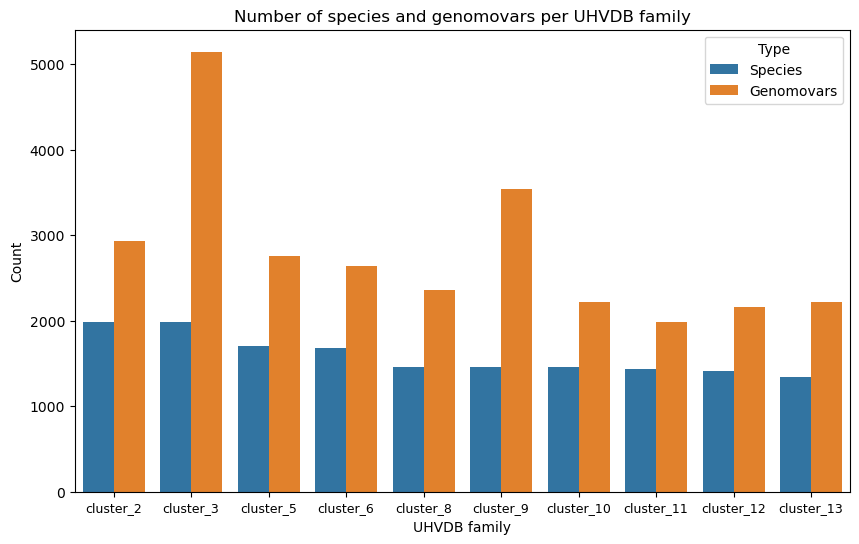

In [33]:
count_df = (
    dsdna_viruses
        .group_by('cluster_id')
        .agg([
            pl.len().alias('Species'),
            pl.col('num_seqs').sum().alias('Genomovars')
        ])
)

# create a barplot of the number of species and genomovars per family
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

count_df_pd = count_df.with_columns([pl.col('cluster_id').str.replace('cluster_', '').cast(pl.Int32).alias('cluster_num')]).sort('cluster_num').to_pandas()
count_df_pd_melted = count_df_pd.melt(id_vars='cluster_id', value_vars=['Species', 'Genomovars'], var_name='Type', value_name='Count')
plt.figure(figsize=(10,6))
sns.barplot(x='cluster_id', y='Count', hue='Type', data=count_df_pd_melted)
plt.ylabel('Count')
plt.xlabel('UHVDB family')
plt.title('Number of species and genomovars per UHVDB family')
# decrease x-axis label text size
plt.xticks(fontsize=9)
plt.show()

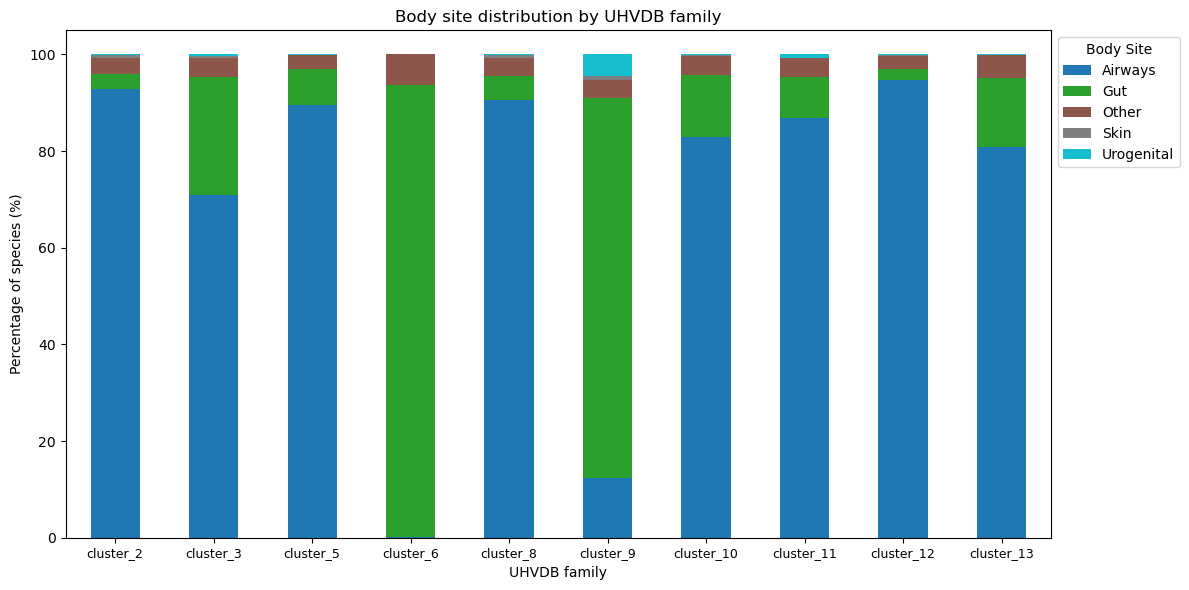

In [37]:
# create stacked barplot of the proportion from each body site by class
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Get counts of each class-body site combination
body_site_data = (
    dsdna_viruses
    .group_by(['cluster_id', 'body_site'])
    .agg(pl.count('seq_name').alias('count'))
    .filter(pl.col('cluster_id').is_not_null())
    .with_columns([pl.col('cluster_id').str.replace('cluster_', '').cast(pl.Int32)])
    .to_pandas()
)

# Pivot to get body sites as columns
pivot_df = body_site_data.pivot(index='cluster_id', columns='body_site', values='count').fillna(0)

# Calculate proportions (normalize by row)
pivot_prop = pivot_df.div(pivot_df.sum(axis=1), axis=0) * 100

# add 'cluster_' prefix back to index
pivot_prop.index = ['cluster_' + str(i) for i in pivot_prop.index]

# Create stacked barplot
ax = pivot_prop.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='tab10')
plt.xlabel('UHVDB family')
plt.ylabel('Percentage of species (%)')
plt.title('Body site distribution by UHVDB family')
plt.legend(title='Body Site', bbox_to_anchor=(1.0, 1), loc='upper left')
plt.xticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

In [28]:
dsdna_viruses

seq_name,cluster_id,ictv_class,db_type,body_site,checkv_quality,length,num_seqs
str,str,str,str,str,str,f64,i64
"""SAMEA2579955_a1_ct20170_vs1@My…",null,"""Caudoviricetes""","""Database""","""Other""","""High-quality""",38700.0,2
"""SAMEA2737684_a1_ct153548_vs1@P…",null,"""Caudoviricetes""","""Database""","""Other""","""High-quality""",17003.0,1
"""SAMEA1906556_a1_ct98905_vs1@Po…",null,"""Caudoviricetes""","""Database""","""Other""","""Complete""",12477.0,1
"""SAMEA2737677_a1_ct57613_vs1@Si…",null,"""Caudoviricetes""","""Database""","""Other""","""High-quality""",41330.0,5
"""SAMEA2737664_a1_ct38140_vs1@Si…",null,"""Caudoviricetes""","""Database""","""Other""","""High-quality""",35979.0,2
…,…,…,…,…,…,…,…
"""UHGV-1431510""",null,"""Caudoviricetes""","""Database""","""Gut""","""High-quality""",68002.0,1
"""UHGV-0060054""",null,"""Caudoviricetes""","""Database""","""Gut""","""Complete""",59017.0,2
"""UHGV-0072709""",null,"""Caudoviricetes""","""Database""","""Gut""","""High-quality""",32601.0,4
